# Task 4: Possession vs Match Outcome in the FIFA World Cup 2026

## Objective 1

### Research Question
Do winning teams have a significantly higher average ball-possession percentage than losing teams in the FIFA World Cup 2026?

This notebook investigates the relationship between ball possession and match outcome using FIFA World Cup 2026 team-level match statistics. A reproducible simple random sample of decisive matches is analysed. All data cleaning, statistical analysis and visualisations are completed in Python.

## Hypotheses

- **H₀:** There is no significant difference in mean ball-possession percentage between winning and losing teams.
- **H₁:** Winning teams have a significantly higher mean ball-possession percentage than losing teams.

The significance level is α = 0.05. A Welch two-sample t-test is used to compare the mean possession of winning and losing teams.

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

RANDOM_SEED = 2026
SAMPLE_MATCHES = 60

# Find the dataset folder
DATA_DIR = Path("data")
if not (DATA_DIR / "matches.csv").exists():
    DATA_DIR = Path.home() / "data"

# Load datasets
matches = pd.read_csv(DATA_DIR / "matches.csv")
team_stats = pd.read_csv(DATA_DIR / "match_team_stats.csv")

print("Matches data shape:", matches.shape)
print("Team statistics shape:", team_stats.shape)

matches.head()

Matches data shape: (104, 17)
Team statistics shape: (208, 12)


,match_id,date,kickoff_time_utc,stage_id,venue_id,home_team_id,away_team_id,home_score,away_score,home_penalty_score,away_penalty_score,status,result_type,home_xg,away_xg,referee_id,player_of_the_match_id
0,1,2026-06-11,19:00,1,1,1,2,2,0,NaN,NaN,Completed,Regular,1.84,0.52,2,16
1,2,2026-06-11,23:00,1,7,3,4,2,1,NaN,NaN,Completed,Regular,1.45,1.12,9,58
2,3,2026-06-12,19:00,1,6,5,6,1,1,NaN,NaN,Completed,Regular,1.35,0.98,11,112
3,4,2026-06-12,23:00,1,3,13,14,4,1,NaN,NaN,Completed,Regular,2.76,0.88,12,332
4,5,2026-06-13,15:00,1,15,7,8,1,1,NaN,NaN,Completed,Regular,0.78,1.54,15,157


In [3]:
# Keep completed matches with a clear winner and loser, then randomly sample match IDs.
decisive = matches.loc[
    matches['home_score'].notna() & matches['away_score'].notna()
    & (matches['home_score'] != matches['away_score'])
].copy()

sampled = decisive.sample(n=min(SAMPLE_MATCHES, len(decisive)), random_state=RANDOM_SEED)

home = sampled[['match_id', 'home_team_id', 'home_score', 'away_score']].rename(columns={
    'home_team_id': 'team_id', 'home_score': 'goals_for', 'away_score': 'goals_against'
})
away = sampled[['match_id', 'away_team_id', 'away_score', 'home_score']].rename(columns={
    'away_team_id': 'team_id', 'away_score': 'goals_for', 'home_score': 'goals_against'
})
team_matches = pd.concat([home, away], ignore_index=True)
team_matches['outcome'] = np.where(team_matches['goals_for'] > team_matches['goals_against'], 'Winner', 'Loser')

analysis = team_matches.merge(
    team_stats[['match_id', 'team_id', 'possession_pct']], on=['match_id', 'team_id'], how='inner'
)
analysis['possession_pct'] = pd.to_numeric(analysis['possession_pct'], errors='coerce')
analysis = analysis.dropna(subset=['possession_pct'])

# Keep only complete winner-loser pairs after the merge.
valid_matches = analysis.groupby('match_id').filter(
    lambda x: len(x) == 2 and x['outcome'].nunique() == 2
)['match_id'].unique()
analysis = analysis[analysis['match_id'].isin(valid_matches)].copy()
print(f'Decisive matches available: {len(decisive)}; analysed sample: {len(valid_matches)}')
analysis.head()

Decisive matches available: 80; analysed sample: 60


,match_id,team_id,goals_for,goals_against,outcome,possession_pct
0,19,37,3,0,Winner,49
1,92,1,2,3,Loser,67
2,44,40,1,2,Loser,29
3,17,33,3,1,Winner,49
4,71,48,0,2,Loser,33


In [4]:
# Descriptive statistics and a 95% confidence interval for winning-team possession
winners = analysis.loc[analysis['outcome'].eq('Winner'), 'possession_pct']
losers = analysis.loc[analysis['outcome'].eq('Loser'), 'possession_pct']
summary = analysis.groupby('outcome')['possession_pct'].agg(['count', 'mean', 'std', 'median', 'min', 'max']).round(2)

winner_mean = winners.mean()
margin = stats.t.ppf(0.975, df=len(winners)-1) * stats.sem(winners)
ci_low, ci_high = winner_mean - margin, winner_mean + margin

display(summary)
print(f'95% CI for mean winning-team possession: {winner_mean:.2f}% [{ci_low:.2f}%, {ci_high:.2f}%]')

,count,mean,std,median,min,max
outcome,,,,,,
Loser,60,42.43,9.45,41.0,20,68
Winner,60,55.57,9.92,57.5,19,76


95% CI for mean winning-team possession: 55.57% [53.00%, 58.13%]


In [5]:
# Welch two-sample t-test: does not assume equal population variances
test = stats.ttest_ind(winners, losers, equal_var=False)
difference = winners.mean() - losers.mean()
pooled_sd = np.sqrt(((len(winners)-1)*winners.var(ddof=1) + (len(losers)-1)*losers.var(ddof=1)) / (len(winners)+len(losers)-2))
cohens_d = difference / pooled_sd
hedges_g = cohens_d * (1 - 3/(4*(len(winners)+len(losers)) - 9))

print(f'Welch t-test: t = {test.statistic:.3f}, p = {test.pvalue:.3e}')
print(f'Mean difference (winner − loser): {difference:.2f} percentage points')
print(f'Hedges g: {hedges_g:.2f}')
print('Decision:', 'Reject H₀: possession differs significantly by outcome.' if test.pvalue < 0.05 else 'Fail to reject H₀.')

Welch t-test: t = 7.424, p = 1.944e-11
Mean difference (winner − loser): 13.13 percentage points
Hedges g: 1.35
Decision: Reject H₀: possession differs significantly by outcome.


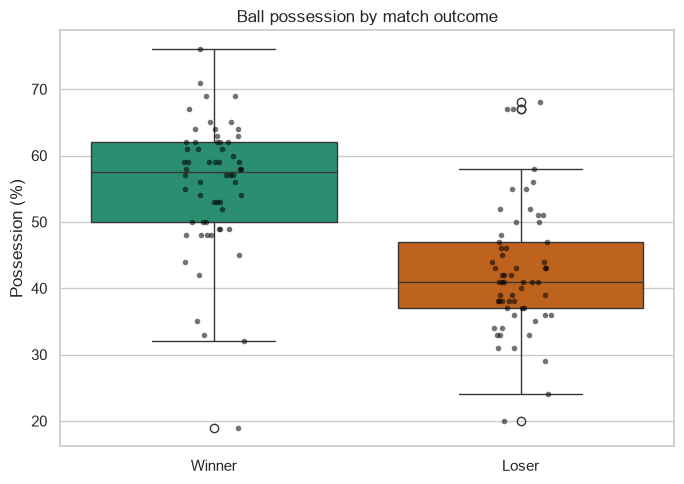

In [6]:
# Presentation-ready visualisation
sns.set_theme(style='whitegrid')
plt.figure(figsize=(7, 5))
sns.boxplot(data=analysis, x='outcome', y='possession_pct', order=['Winner', 'Loser'], hue='outcome', legend=False, palette=['#1b9e77', '#d95f02'])
sns.stripplot(data=analysis, x='outcome', y='possession_pct', order=['Winner', 'Loser'], color='black', alpha=0.55, size=4)
plt.title('Ball possession by match outcome')
plt.xlabel('')
plt.ylabel('Possession (%)')
plt.tight_layout()
plt.savefig('task4_possession_by_outcome.png', dpi=300, bbox_inches='tight')
plt.show()

analysis.to_csv('task4_clean_team_match_sample.csv', index=False)
summary.to_csv('task4_descriptive_statistics.csv')

In [7]:
# Welch two-sample t-test

winners = analysis.loc[analysis["outcome"] == "Winner", "possession_pct"]
losers = analysis.loc[analysis["outcome"] == "Loser", "possession_pct"]

test = stats.ttest_ind(winners, losers, equal_var=False)

print(f"t-statistic = {test.statistic:.3f}")
print(f"p-value = {test.pvalue:.12f}")
print(f"Mean difference = {winners.mean() - losers.mean():.2f}%")

if test.pvalue < 0.05:
    print("Decision: Reject H₀ — winners had significantly higher possession.")
else:
    print("Decision: Fail to reject H₀.")

t-statistic = 7.424
p-value = 0.000000000019
Mean difference = 13.13%
Decision: Reject H₀ — winners had significantly higher possession.


## Statistical Test Result and Interpretation

A Welch two-sample t-test was conducted to compare the mean ball-possession percentage of winning and losing teams.

- **t-statistic:** 7.424  
- **p-value:** < 0.001  
- **Mean difference:** 13.13 percentage points  

Since the p-value is less than the significance level of 0.05, the null hypothesis is rejected. Winning teams had a significantly higher average ball-possession percentage than losing teams in the sampled decisive FIFA World Cup 2026 matches.

## Result and interpretation
With the current dataset and seed, winners averaged **55.57%** possession (SD = **9.92**) and losers averaged **42.43%** (SD = **9.45**). The 95% CI for the winners' mean was **53.00% to 58.13%**. Welch's t-test gave **t = 7.424, p < .001**, so H₀ is rejected.

Winning teams had higher possession in this sample. This is an association, not proof that possession itself causes a win: tactics, scoreline, shots, defensive strength and finishing may also affect both possession and result.

## References
Islam, M. M. (2026). *The FIFA World Cup 2026 Master Dataset: A normalized 3NF relational benchmark of the expanded 48-team international football tournament* (Version 1.0.0) [Data set]. Zenodo. https://doi.org/10.5281/zenodo.21592427

FIFA Training Centre. (2026). *Match report hub: FIFA World Cup 2026™ — Group stage*. https://www.fifatrainingcentre.com/en/fifa-world-cup-2026/match-report-hub.php
